<a href="https://colab.research.google.com/github/SquidsofDoom/QCES/blob/main/Project3_tsunami.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Tsunami - Sebastien Montemurro
In this project, we will use Dedalus to model the propagation of Tsunami waves. Tsunami typically have wavelengths larger than 100km and periods of about 1 hour. Since their wavelength is much larger than the depth of the ocean, Tsunami can be modelled using the shallow water equations.

Here, we will use Dedalus to solve an initial value problem for the shallow water equations. We will generate a Tsunami using a localized disturbance to the water height.

Student tasks are in [Section 1.3]( #section1pt3 ), [Section 2.3]( #section2pt3 ), and [Section 3.3]( #section3pt3 ).

## Setup
If you are using Google colab, run the script below to install Dedalus

In [1]:
# Set environment variables for best performance
%env OMP_NUM_THREADS=1
%env NUMEXPR_MAX_THREADS=1

# Minimize logging output
import logging
logging.disable(logging.DEBUG)

# Check if running on google colab
import os
using_google_colab = bool(os.getenv("COLAB_RELEASE_TAG"))

# Check for Dedalus
try:
    import dedalus.public as de
    print("Dedalus already installed :)")
except:
    print("Dedalus not installed yet.")
    if using_google_colab:
        print("Installing for Google Colab.")
        print()
        # Step 1: Install FFTW
        !apt-get install libfftw3-dev
        !apt-get install libfftw3-mpi-dev
        # Step 2: Set paths for Dedalus installation
        import os
        os.environ['MPI_INCLUDE_PATH'] = "/usr/lib/x86_64-linux-gnu/openmpi/include"
        os.environ['MPI_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        os.environ['FFTW_INCLUDE_PATH'] = "/usr/include"
        os.environ['FFTW_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        # Step 3: Install Dedalus using pip
        !pip3 install cython "mpi4py<4.0" numpy setuptools wheel
        !CC=mpicc pip3 install --no-cache --no-build-isolation http://github.com/dedalusproject/dedalus/zipball/master/
        !pip3 install -q ipympl
        # Step 4: Check installation
        print()
        try:
            import dedalus.public as de
            print("Dedalus successfully installed :)")
        except:
            print("Error installing Dedalus :(")
            raise
    else:
        print("See website for installation instructions:")
        print("https://dedalus-project.readthedocs.io/en/latest/pages/installation.html")

# Setup interactive matplotlib
if using_google_colab:
    from google.colab import output
    output.enable_custom_widget_manager()

env: OMP_NUM_THREADS=1
env: NUMEXPR_MAX_THREADS=1
Dedalus not installed yet.
Installing for Google Colab.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libfftw3-bin libfftw3-double3 libfftw3-long3 libfftw3-quad3 libfftw3-single3
Suggested packages:
  libfftw3-doc
The following NEW packages will be installed:
  libfftw3-bin libfftw3-dev libfftw3-double3 libfftw3-long3 libfftw3-quad3
  libfftw3-single3
0 upgraded, 6 newly installed, 0 to remove and 41 not upgraded.
Need to get 4,654 kB of archives.
After this operation, 24.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-double3 amd64 3.3.8-2ubuntu8 [770 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-long3 amd64 3.3.8-2ubuntu8 [335 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-quad3 amd64 3.3.8-2ubuntu8 [614 kB]
Get:4 http://arch

## 1.  1D shallow water equations
Let's start by solving the shallow water equations in 1D with periodic boundary conditions in our spatial variable, $x$. The script below solves the following equations:

$$ \partial_t u + g \partial_x(h) = - u\partial_x u$$
$$ \partial_t h + \partial_x(Hu) = -\partial_x(hu)$$

In these equations, $g$ is the constant gravitational acceleration, $u$ is the velocity in the $x$ direction, $H$ is the resting height, and $h$ is the height of the free surface relative to $H$. Note that the terms on the right hand side are nonlinear in our dependent variables, and we will use an explicit timestepping method for these terms. Recall that Dedalus uses explicit timestepping for terms on the right hand side of the inputted equation.

Because we are interested in an application to Tsunami, we will solve the equations using dimensional variables. It is convenient to define simulation units at the start of the script so that we can be explicit about the units.

We will start with the following initial conditions:
$$ h=e^{-(x-x_1)^2/w_1^2} $$
$$ u=0 $$
where $x_1$ is the center and $w_1=100$ km is the width of the Gaussian perturbation.

To see how the waves change as they approach shallow water, we will set the resting water depth to include a localized seamount using the form:
$$ H=H_0-(H_0-H_{min})e^{(-(x-x_2)^2/w_2^2)} $$
where $x_2$ is the location of the seamount, $H_0=4$ km is the depth of the ocean away from the seamount, and $H_{min}$ is the minimum water depth above the seamount. Note that since $H\ll w$, the shallow water approximation is appropriate here.

### 1.1  Dedalus script to solve the 1D shallow water equations

The script below solves the 1D shallow water equations with the initial conditions given above.

In [3]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 2000 * kilometer # The domain size
Nx = 512 # The number of gridpoints in x
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
w1 = 20 * kilometer # Width of the initial perturbation
x1 = 200 * kilometer # Center of the initial perturbation
x2 = 500 * kilometer # Center of the seamount
w2 = 100 * kilometer # Width of the seamount
H_min = 100 * meter # minimum depth above the seamount

timestep = 60 * second # Specify the timestep
stop_sim_time = 100 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Create an x-coordinate, a corresponding basis, and a distributor
xcoord = dedalus.Coordinate('x')
dist = dedalus.Distributor(xcoord, dtype=np.float64) # No mesh for serial / automatic parallelization
x_basis = dedalus.RealFourier(xcoord, size=Nx, bounds=(0, Lx))
x = dist.local_grid(x_basis)

# Specify the Fields and set the initial conditions
u = dist.Field(name='u', bases=x_basis)
h = dist.Field(name='h', bases=x_basis)
H = dist.Field(name='H', bases=x_basis)
h.change_scales(1)
H.change_scales(1)
u.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-(x-x2)**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2.0/w1**2.0)  # Initialize the height with a Gaussian function with width set above
u['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, xcoord)

# Problem
problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u)")
problem.add_equation("dt(h) + dx(H*u) = - dx(h*u)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

INFO:subsystems:Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.2e+01/s


2025-11-19 22:14:45,467 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.2e+01/s


INFO:__main__:Starting main loop


2025-11-19 22:14:45,475 __main__ 0/1 INFO :: Starting main loop


INFO:solvers:Simulation stop time reached.


...

2025-11-19 22:14:45,697 solvers 0/1 INFO :: Run time (iter 10-end): 0.1423 sec


INFO:solvers:CPU time (iter 10-end): 3.953e-05 cpu-hr


2025-11-19 22:14:45,699 solvers 0/1 INFO :: CPU time (iter 10-end): 3.953e-05 cpu-hr


INFO:solvers:Speed: 1.293e+06 mode-stages/cpu-sec


2025-11-19 22:14:45,701 solvers 0/1 INFO :: Speed: 1.293e+06 mode-stages/cpu-sec


### 1.2  Plotting
The code below will make a movie of the height.

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-19 22:14:48,751 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp4ux8h_m1/temp.m4v


2025-11-19 22:14:48,754 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp4ux8h_m1/temp.m4v


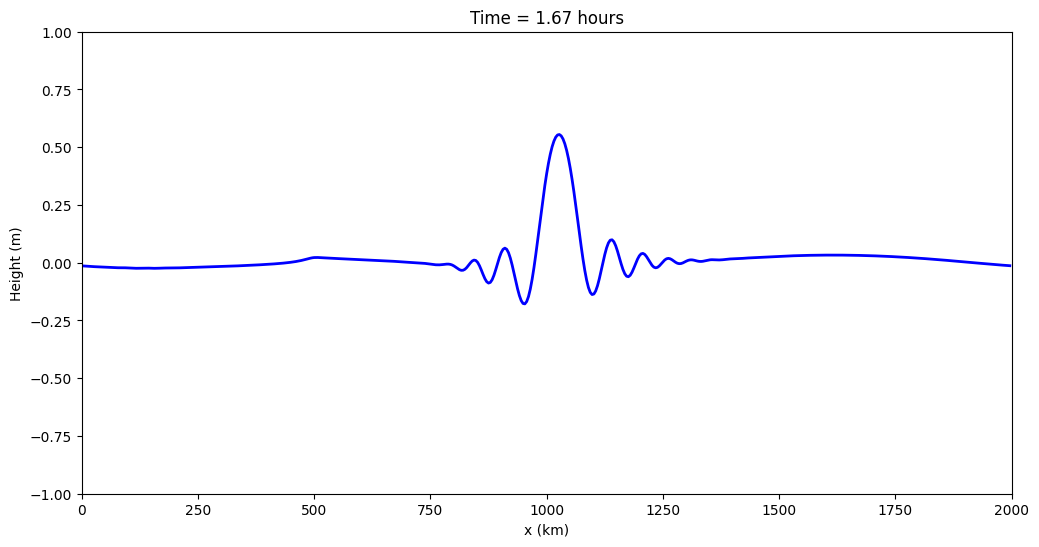

In [4]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Specify the axis limits and labels
plt.xlim((0, Lx / (1*kilometer)))
plt.ylim((-1, 1))
plt.xlabel('x (km)')
plt.ylabel('Height (m)')

# Create objects that will change during the animation
txt_title = plt.title('')
height, = plt.plot([], [], 'b', lw=2)

# Define an animation function
def drawframe(n):
    height.set_data(x/(1*kilometer), h_save[n,:])
    txt_title.set_text('Time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())


### 1.3 Student investigation
<a id='section1pt3'></a>
In the cells below, provide an expression for the expected wave speed and state any assumptions that are necessary to arrive at this. Then plot the wave speed from the output above and compare this with the expected value.

<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-61945140.py:49: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(x=popt[1],linestyle='--',label=f'$\mu$ = {popt[1]}')
/tmp/ipython-input-61945140.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xh_max[i] = np.where(h_save[i]==h_max[i])[0]


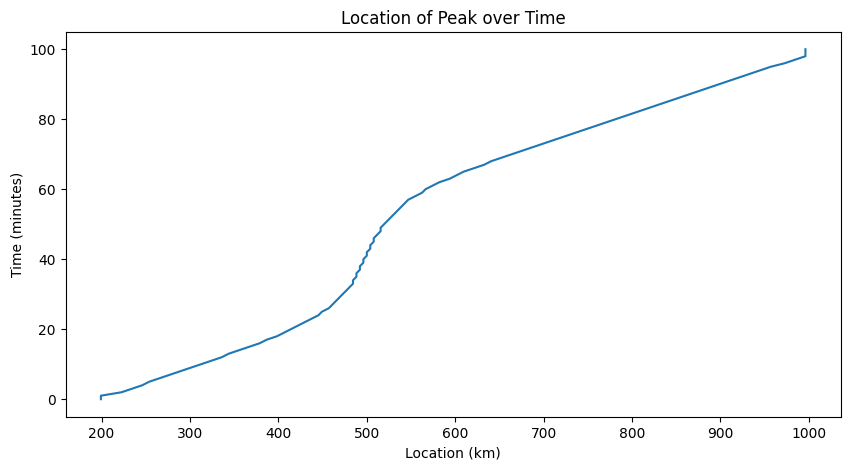

/tmp/ipython-input-61945140.py:41: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(h + a*np.exp(-(x-x0)**2/(2*sigma**2)))


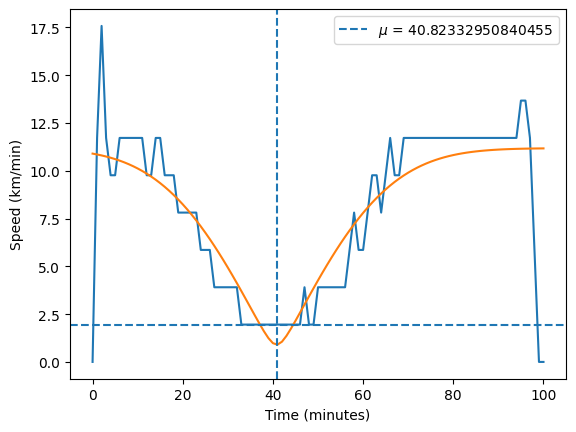

[-124.21006688   40.82332951  -16.69583776  125.020311  ]


In [5]:
plt.figure(figsize=(10,5))

h_save = h_save*meter # rescaling (doesn't do anything!)
t_save = np.array(t_save)
t_savem = t_save/minute # going to be handy when plotting soon


# initialising the arrays to store the value and location of each max point
h_max = np.zeros(len(h_save))
xh_max = np.zeros(len(h_save))
# sifting through the arrays to find each max value and its x coord
for i in range(len(h_save)):
  h_max[i] = np.max(h_save[i,50:256])
  xh_max[i] = np.where(h_save[i]==h_max[i])[0]


xh_max = xh_max * Lx/(Nx*kilometer) # rescaling the x-coord for plotting


ax1 = fig.add_subplot(1,2,1)
plt.plot(xh_max,t_save/np.array(1*minute))
plt.title('Location of Peak over Time')
plt.ylabel('Time (minutes)')
plt.xlabel('Location (km)')
plt.show()



from scipy.optimize import curve_fit

wave_speed = np.gradient(xh_max) # calculate how the peak's location moves with time (ie. velocity)
avg_speed = np.mean(np.abs(wave_speed)) # just in case i need the average speed!


def gaus(x,a,x0,sigma,h):
  '''defines a gaussian function with basically every degree of freedom. will be used to make a fit later
  inputs: a bunch of parameters (floats)
          x - input array along x axis
  outputs: y - output array along y axis. is a bell function/Gaussian
  '''
  return np.sqrt(h + a*np.exp(-(x-x0)**2/(2*sigma**2)))

# initial conditions to look out for! mean and std were found in their seconds form and then converted to minutes
mean = 2500/minute
std = 1000/minute
popt, pcov = curve_fit(gaus,t_savem,wave_speed,p0=[-2.5,mean,std,3])
plt.plot(t_save/minute,wave_speed)
plt.plot(t_savem,gaus(t_savem,*popt))
plt.axvline(x=popt[1],linestyle='--',label=f'$\mu$ = {popt[1]:.2f}')
plt.axhline(y=np.min(wave_speed[10:-10]),linestyle='--')
plt.legend()
plt.xlabel('Time (minutes)')
plt.ylabel('Speed (km/min)')
plt.show()
print(popt)

We are looking here at the shallow water equation, which we can find under the assumptions $f = 0$, and that the wave is travelling along the equator ($v = 0$ and all $y$ derivatives are 0). The equations simplify to the following wave equation:

$$
\frac{\partial^2 h}{\partial t^2} = g H \frac{\partial^2 h}{\partial x^2}
$$
Which we can see is a wave which propagates with speed
$$
c = \sqrt{gH} = \sqrt{g(H_0-(H_0-H_{min})e^{-(x-x_2)^2/w_2^2)})}
$$
Which would have a 'sharp Gaussian' shape and a minimum point at $c_{min} = \sqrt{gH_{min}}$. A fit was made of a square-rooted Gaussian function to the speeds above, and we see the general shape is well described by the Gaussian shape. A minimum value of $c=0.903km/min$ was found to be the minimum, suggesting $H_{min} \approxeq 23.12m$. This seems a little close to the surface, and using the minimum value of the model, not the Gaussian fit, we find that $H_{min} \approxeq 107.67m$. The difference in length scales (km on the x axis and m on the y axis) means that discrepencies or larger variances in the Gaussian fit will cause very large over- or underestimations in the height axis - this is expected, given we are looking at a shallow water system.
Far from the mound, we can calculate that the speed is around $c = \sqrt{gH_0} = 11.89km/min$, which is close to the far-field value from the Gaussian fit, $c = 11.18 km/min.$

Qualitatively, the wave slows down at the mound, speeding up again after passing it. This happens at around 40 minutes, where the mean of the Gaussian was calculated.

## 2.  2D Shallow water equations

Now, let's see how things change if we move to two dimensions. The script below solves the 2D shallow water equations:

$$ \partial_t u + g \partial_x(h) = - u*\partial_x u - v*\partial_y u$$
$$ \partial_t u + g \partial_y(h) = - u*\partial_x v - v*\partial_y v$$
$$ \partial_t h + \partial_x(u*H) + \partial_y(v*H)) = -\partial_x(h*u) - \partial_y(h*v)$$

We will initilize the Tsunami with the following equation
$$ h=e^{-x^2/w_1^2} $$
$$ u=(g/c)*h $$

where $c=\sqrt{gH_0}$ and $H_0$ is the constant reference depth. The relationship between $u$ and $h$ follows from linearized shallow water equations and corresponds to a wave propagating in the $+x$ direction with a speed $c$.

We will solve the equations in a square domain with periodic boundary conditions and a Gaussian seamount in the middle of the domain with height

$$ H=H_{min}e^{-(x^2+y^2)/w_2^2} $$

The Tsunami should propagate with speed $c$ over the deep ocean where the depth is constant, but the wave will be modified as it passes over the seamount.

### 2.1  Dedalus script to solve the 2D shallow water equations

In [249]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size in x
Ly = 1000 * kilometer # The domain size in y
Nx = 64 # The number of gridpoints in x
Ny = 64 # The number of gridpoints in y
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
c = np.sqrt(g*H0) # Wave speed over the deep ocean
H_min = 1 * kilometer # minimum depth above the seamount
w1 = 50 * kilometer # Set the width of the wave
w2 = 200 * kilometer # Width of the seamount
x1 = -300 * kilometer # Center of the wave at t=0

timestep = 60 * second # Specify the timestep
stop_sim_time = 100 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Bases
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

x, y = dist.local_grids(xbasis, ybasis)

# Fields
u = dist.Field(name='u', bases=(xbasis, ybasis))
v = dist.Field(name='v', bases=(xbasis, ybasis))
h = dist.Field(name='h', bases=(xbasis, ybasis))
H = dist.Field(name='H', bases=(xbasis, ybasis))

# Initial conditions
H.change_scales(1)
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
v.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-x**2.0/w2**2.0 - y**2.0/(w2**2.0))
h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
u['g'] = (g/c)*h['g']
v['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, coords['x'])
dy = lambda a: dedalus.Differentiate(a, coords['y'])

# Problem
problem = dedalus.IVP([u, v, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')
snapshots.add_task(v, name='v')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

INFO:subsystems:Building subproblem matrices 1/1 (~100%) Elapsed: 19s, Remaining: 0s, Rate: 5.2e-02/s


2025-11-20 00:47:16,487 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 19s, Remaining: 0s, Rate: 5.2e-02/s


INFO:__main__:Starting main loop


2025-11-20 00:47:16,494 __main__ 0/1 INFO :: Starting main loop


INFO:solvers:Simulation stop time reached.


...

2025-11-20 00:47:30,321 solvers 0/1 INFO :: Run time (iter 10-end): 8.402 sec


INFO:solvers:CPU time (iter 10-end): 0.002334 cpu-hr


2025-11-20 00:47:30,322 solvers 0/1 INFO :: CPU time (iter 10-end): 0.002334 cpu-hr


INFO:solvers:Speed: 2.551e+05 mode-stages/cpu-sec


2025-11-20 00:47:30,325 solvers 0/1 INFO :: Speed: 2.551e+05 mode-stages/cpu-sec


### 2.2  Plotting
The code below will make a movie of the height as a function of x and y

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-20 00:52:50,890 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmporgj337k/temp.m4v


2025-11-20 00:52:50,893 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmporgj337k/temp.m4v


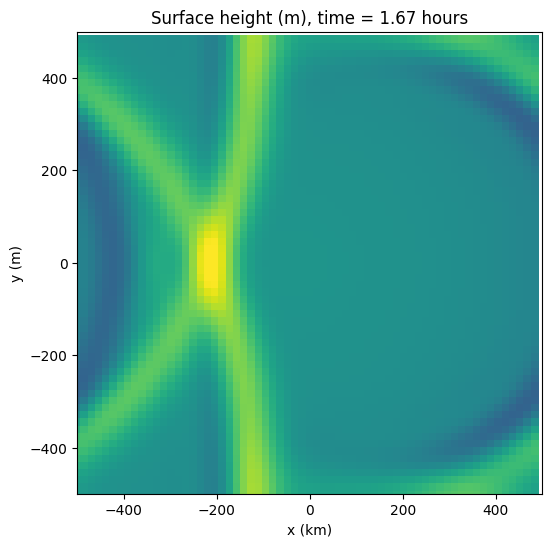

In [251]:
# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the x and y coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))

# Define an animation function
def drawframe(n):
    plt.clf # clear the figure before plotting the next frame
    height = plt.pcolor(X/(1*kilometer), Y/(1*kilometer), h_save[n,:,:].T, vmin=-1, vmax=1)
    plt.Circle( (0, 0 ), w2, fill = False, linestyle='--' ) # drawing the mound
    plt.xlim((-Lx/2 / (1*kilometer),Lx/2 / (1*kilometer)))
    plt.ylim((-Ly/2 / (1*kilometer),Ly/2 / (1*kilometer)))
    plt.xlabel('x (km)')
    plt.ylabel('y (m)')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

### 2.3 Student investigation
<a id='section2pt3'></a>
Qualitatively describe the influence of the seamount and explain this behavior using the shallow water equations. You can assume that the wave amplitude and velocity are small in the shallow water equations.

From the equation of wavespeed, we see that a decrease in $H$ causes a reduction of $c$ locally. As the wave front approaches the mound, different parts are slowed down at different times as they separately reach the mound. Given the circularity of the mound, it appears that the wave 'bends' around the mound. There is a slight reflection from this mound backwards. Immediately after the wave passes over the island, both parts of the wave bend around the mound symmetrically and interact, causing constructive interference. Behind this wake is the constructive depression in the wave height, corresponding to the dark blue. Diffraction occurs when the wavelength is smaller than or approximately equal to the mound size, which here means $


Try varying some parameters (e.g. the width and height of the wave and/or seamount) and comment on the results. When does the wave no longer obey the linear shallow water equations which are valid for small waves You don't need to do a comprehensive parameter space search, but you should run several simulations with one or two parameters varied.

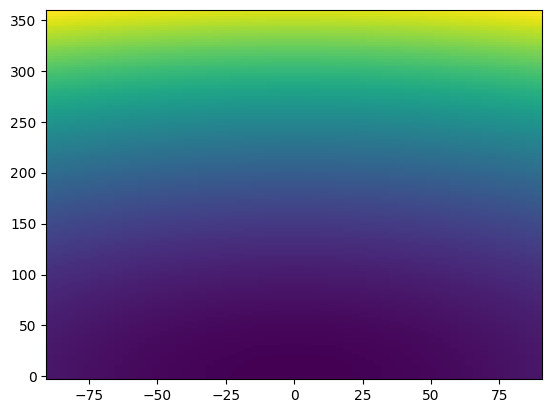

In [287]:
def mound1(x,y,H0,H_min,w2):
  heights = H0-(H0-H_min)*np.exp(-x**2.0/w2**2.0 - y**2.0/(w2**2.0))
  return heights
xinput = len(X[0,:])# to fix formatting of x
yinput = len(Y[0,:])
#plt.pcolor(mound1(X,Y,H0,H_min,w2))

def mound2(x,y,H0,H_min,l1,l2):
  x = X[0,:]
  y = Y[:,0]
  xsize = len(x)
  ysize = len(y)
  heights = H0*np.ones((xsize,ysize))
  for i in range(int(xsize//2-l1//2),int(xsize//2+l1//2)):
    for j in range(int(ysize//2-l2//2),int(ysize//2+l2//2)):
      heights[i,j] = H_min
  return heights
#plt.pcolor(X,Y,mound2(X,Y,H0,H_min,25,5))

def mound3(x,y,H0,H_min,w2):
  heights = H0 + (H_min-H0)*(x**2 + y**2)
  return heights
plt.pcolor(X,Y,mound1(X,Y,H0,H_min,w2))

In [289]:
def change_w2(w2_val):
    logger = logging.getLogger(__name__)

    # units
    meter = 1
    kilometer = meter * 1e3
    second = 1
    minute = 60
    hour = 3600
    day = hour * 24

    # simulation parameters
    Lx = 1000 * kilometer # The domain size in x
    Ly = 1000 * kilometer # The domain size in y
    Nx = 64 # The number of gridpoints in x
    Ny = 64 # The number of gridpoints in y
    g = 9.81 * meter / second**2 # Gravitational acceleration
    H0 = 4 * kilometer # Reference ocean depth
    c = np.sqrt(g*H0) # Wave speed over the deep ocean
    H_min = 1 * kilometer # Minimum depth above the seamount
    w1 = 50 * kilometer # Set the width of the wave
    # w2 is an argument (w2_val)
    x1 = -300 * kilometer # Center of the wave at t=0

    timestep = 60 * second # Specify the timestep
    stop_sim_time = 60 * minute # Specify the stopping time

    # Bases
    coords = dedalus.CartesianCoordinates('x', 'y')
    dist = dedalus.Distributor(coords, dtype=np.float64)
    xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
    ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

    x, y = dist.local_grids(xbasis, ybasis)

    # Fields
    u = dist.Field(name='u', bases=(xbasis, ybasis))
    v = dist.Field(name='v', bases=(xbasis, ybasis))
    h = dist.Field(name='h', bases=(xbasis, ybasis))
    H = dist.Field(name='H', bases=(xbasis, ybasis))

    # Initial conditions
    H.change_scales(1)
    h.change_scales(1) # Set values on regular grid
    u.change_scales(1)
    v.change_scales(1)
    # Use the provided w2_val for the seamount width
    H['g'] = H0-(H0-H_min)*np.exp(-x**2.0/w2_val**2.0 - y**2.0/w2_val**2.0)
    h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
    u['g'] = (g/c)*h['g']
    v['g'] = 0

    # Operators
    dx = lambda a: dedalus.Differentiate(a, coords['x'])
    dy = lambda a: dedalus.Differentiate(a, coords['y'])

    # Problem
    problem = dedalus.IVP([u, v, h], namespace=locals())
    problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
    problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
    problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

    # Solver
    solver = problem.build_solver(dedalus.RK222)
    solver.stop_sim_time = stop_sim_time

    h_save_local = []
    t_save_local = []

    h.change_scales(1)
    h_save_local.append(np.copy(h['g']))
    t_save_local.append(solver.sim_time)

    # Main loop
    try:
        logger.info(f'Starting main loop for w2 = {w2_val / kilometer} km')
        while solver.proceed:
            solver.step(timestep)
            if (solver.iteration-1) % 1 == 0:
                h.change_scales(1)
                h_save_local.append(np.copy(h['g']))
                t_save_local.append(solver.sim_time)
    except Exception as e:
        logger.error(f'Exception raised for w2 = {w2_val / kilometer} km: {e}')
        raise

    return np.array(h_save_local), np.array(t_save_local), x, y
'''
def change_mound(mound):
    logger = logging.getLogger(__name__)

    # units...
    meter = 1
    kilometer = meter * 1e3
    second = 1
    minute = 60
    hour = 3600
    day = hour * 24

    # simulation parameters
    Lx = 1000 * kilometer # The domain size in x
    Ly = 1000 * kilometer # The domain size in y
    Nx = 64 # The number of gridpoints in x
    Ny = 64 # The number of gridpoints in y
    g = 9.81 * meter / second**2 # Gravitational acceleration
    H0 = 4 * kilometer # Reference ocean depth
    c = np.sqrt(g*H0) # Wave speed over the deep ocean
    H_min = 1*kilometer
    w1 = 50 * kilometer # Set the width of the wave
    w2 = 200 * kilometer # Width of the seamount
    x1 = -300 * kilometer # Center of the wave at t=0

    timestep = 60 * second # Specify the timestep
    stop_sim_time = 60 * minute # Specify the stopping time

    # Bases
    coords = dedalus.CartesianCoordinates('x', 'y')
    dist = dedalus.Distributor(coords, dtype=np.float64)
    xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
    ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

    x, y = dist.local_grids(xbasis, ybasis)

    # Fields
    u = dist.Field(name='u', bases=(xbasis, ybasis))
    v = dist.Field(name='v', bases=(xbasis, ybasis))
    h = dist.Field(name='h', bases=(xbasis, ybasis))
    H = dist.Field(name='H', bases=(xbasis, ybasis))

    # Initial conditions
    H.change_scales(1)
    h.change_scales(1) # Set values on regular grid
    u.change_scales(1)
    v.change_scales(1)
    # Use the provided H_min_val for the seamount width
    H['g'] = mound
    h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
    u['g'] = (g/c)*h['g']
    v['g'] = 0

    # Operators
    dx = lambda a: dedalus.Differentiate(a, coords['x'])
    dy = lambda a: dedalus.Differentiate(a, coords['y'])

    # Problem
    problem = dedalus.IVP([u, v, h], namespace=locals())
    problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
    problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
    problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

    # Solver
    solver = problem.build_solver(dedalus.RK222)
    solver.stop_sim_time = stop_sim_time

    h_save_local = []
    t_save_local = []

    h.change_scales(1)
    h_save_local.append(np.copy(h['g']))
    t_save_local.append(solver.sim_time)

    # Main loop
    try:
        logger.info(f'Starting main loop for H_min = {H_min_val / kilometer} km')
        while solver.proceed:
            solver.step(timestep)
            if (solver.iteration-1) % 1 == 0:
                h.change_scales(1)
                h_save_local.append(np.copy(h['g']))
                t_save_local.append(solver.sim_time)
    except Exception as e:
        logger.error(f'Exception raised for H_min = {H_min_val / kilometer} km: {e}')
        raise

    return np.array(h_save_local), np.array(t_save_local), x, y

'''

'\ndef change_mound(mound):\n    logger = logging.getLogger(__name__)\n\n    # units...\n    meter = 1\n    kilometer = meter * 1e3\n    second = 1\n    minute = 60\n    hour = 3600\n    day = hour * 24\n\n    # simulation parameters\n    Lx = 1000 * kilometer # The domain size in x\n    Ly = 1000 * kilometer # The domain size in y\n    Nx = 64 # The number of gridpoints in x\n    Ny = 64 # The number of gridpoints in y\n    g = 9.81 * meter / second**2 # Gravitational acceleration\n    H0 = 4 * kilometer # Reference ocean depth\n    c = np.sqrt(g*H0) # Wave speed over the deep ocean\n    H_min = 1*kilometer\n    w1 = 50 * kilometer # Set the width of the wave\n    w2 = 200 * kilometer # Width of the seamount\n    x1 = -300 * kilometer # Center of the wave at t=0\n\n    timestep = 60 * second # Specify the timestep\n    stop_sim_time = 60 * minute # Specify the stopping time\n\n    # Bases\n    coords = dedalus.CartesianCoordinates(\'x\', \'y\')\n    dist = dedalus.Distributor(coords, 

In [282]:
mound_array = [mound1(X,Y,H0,H_min,w2), mound2(X,Y,H0,H_min,25,5), mound3(X,Y,H0,H_min,w2)]
print(len(mound_array[0][0,:]))

65


In [290]:
w2array = [50 * kilometer, 100 * kilometer, 200 * kilometer]
w2_output = []

for w2_val in w2array:
    h_save_data, t_save_data, x_data, y_data = change_w2(w2_val)
    w2_output.append((h_save_data, t_save_data, x_data, y_data))


mound_array = [mound1(X,Y,H0,H_min,w2), mound2(X,Y,H0,H_min,25,5), mound3(X,Y,H0,H_min,w2)]
mound_output = []

for m in mound_array:
    h_save_data, t_save_data, x_data, y_data = change_mound(m)
    mound_output.append((h_save_data, t_save_data, x_data, y_data))


from dedalus.extras import plot_tools

fig, axes = plt.subplots(1, len(w2array), figsize=(4 * len(w2array), 3), squeeze=False)
axes = axes.flatten()

for i, (w2_val, (h_save_data, t_save_data, x_data, y_data)) in enumerate(zip(w2array, w2_output)):
    ax = axes[i]
    # Plot the final time step of the height field
    h_final = h_save_data[-1, :, :]
    (X, Y) = plot_tools.quad_mesh(np.squeeze(x_data), np.squeeze(y_data))
    im = ax.pcolormesh(X/(1*kilometer), Y/(1*kilometer), h_final.T, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xlim((-Lx/2 / (1*kilometer), Lx/2 / (1*kilometer)))
    ax.set_ylim((-Ly/2 / (1*kilometer), Ly/2 / (1*kilometer)))
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_title(f'Final height (m)\nw2 = {w2_val/kilometer:.0f}km')
    fig.colorbar(im, ax=ax, label='Height (m)')

plt.tight_layout()
plt.show()

# now for H_min...
fig, axes = plt.subplots(1, len(mound_array), figsize=(4 * len(mound_array), 3), squeeze=False)
axes = axes.flatten()

for i, (H_min_val, (h_save_data, t_save_data, x_data, y_data)) in enumerate(zip(mound_array), mound_output):
    ax = axes[i]
    # Plot the final time step of the height field
    h_final = h_save_data[-1, :, :]
    (X, Y) = plot_tools.quad_mesh(np.squeeze(x_data), np.squeeze(y_data))
    im = ax.pcolormesh(X/(1*kilometer), Y/(1*kilometer), h_final.T, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xlim((-Lx/2 / (1*kilometer), Lx/2 / (1*kilometer)))
    ax.set_ylim((-Ly/2 / (1*kilometer), Ly/2 / (1*kilometer)))
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_title(f'Final height (m)\nH_min = {H_min_val/kilometer:.1f}km')
    fig.colorbar(im, ax=ax, label='Height (m)')

plt.tight_layout()
plt.show()

INFO:subsystems:Building subproblem matrices 1/1 (~100%) Elapsed: 13s, Remaining: 0s, Rate: 7.6e-02/s


2025-11-20 01:55:27,916 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 13s, Remaining: 0s, Rate: 7.6e-02/s


INFO:__main__:Starting main loop for w2 = 50.0 km


2025-11-20 01:55:27,921 __main__ 0/1 INFO :: Starting main loop for w2 = 50.0 km


INFO:solvers:Simulation stop time reached.


...

INFO:__main__:Starting main loop for w2 = 200.0 km


2025-11-20 01:56:12,769 __main__ 0/1 INFO :: Starting main loop for w2 = 200.0 km


INFO:solvers:Simulation stop time reached.


2025-11-20 01:56:23,405 solvers 0/1 INFO :: Simulation stop time reached.


ValueError: could not broadcast input array from shape (129,65) into shape (64,64)

In [ ]:
#plt.pcolor(np.array([[1,2],[2,3],[3,4]]))

#h['g'][]

As stated above, the waves diffract around the island when it has a Gaussian shape. To test how different shapes would change the diffraction, two new shapes were made for the mound - one that is a hard 'barrier' step function, and the other is a saddle. We see that for the barrier, there is less diffraction in the central parts. As explained above, the diffraction happens as different parts of the waves slow down due to the mound at different times. As the mound is perpendicular to the wave travel, the wavefront reaches it at the same time, and so the central bit doesn't bend. For saddle contour on the ground is intending to model a seafloor that varies smoothly, perhaps near a coastal area.

In [ ]:
def shape_change(moundfun):
  '''runs the function
  '''
  # Bases
  coords = dedalus.CartesianCoordinates('x', 'y')
  dist = dedalus.Distributor(coords, dtype=np.float64)
  xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
  ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

  x, y = dist.local_grids(xbasis, ybasis)

  # Fields
  u = dist.Field(name='u', bases=(xbasis, ybasis))
  v = dist.Field(name='v', bases=(xbasis, ybasis))
  h = dist.Field(name='h', bases=(xbasis, ybasis))
  H = dist.Field(name='H', bases=(xbasis, ybasis))

  # Initial conditions
  H.change_scales(1)
  h.change_scales(1) # Set values on regular grid
  u.change_scales(1)
  v.change_scales(1)
  H['g'] = moundfun
  h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
  u['g'] = (g/c)*h['g']
  v['g'] = 0

  # Operators
  dx = lambda a: dedalus.Differentiate(a, coords['x'])
  dy = lambda a: dedalus.Differentiate(a, coords['y'])

  # Problem
  problem = dedalus.IVP([u, v, h], namespace=locals())
  problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
  problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
  problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

  # Solver
  solver = problem.build_solver(dedalus.RK222)
  solver.stop_sim_time = stop_sim_time

  # Analysis
  snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
  snapshots.add_task(h, name='h')
  snapshots.add_task(u, name='u')
  snapshots.add_task(v, name='v')

  h.change_scales(1)
  h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
  # Main loop
  try:
      logger.info('Starting main loop')
      while solver.proceed:
          solver.step(timestep)
          if (solver.iteration-1) % 1 == 0:
              h.change_scales(1)
              h_save.append(np.copy(h['g']))
              t_save.append(solver.sim_time)
  except:
      logger.error('Exception raised, triggering end of main loop.')
      raise
  finally:
      solver.log_stats()

  h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

  return h_save



## 3. Shallow water equations on a sphere

Of course the Earth isn't a flat plane. A great strength of Dedalus is its flexibility to solve equations in various geometries. The script below solves the 2D shallow water equations on a spherical shell, where the azimuth and colatitude are the independent variables. The colatitude is the complementary angle to the latitude such that the colatitude is $0^\circ$ at the North Pole, $90^\circ$ at the Equator, and $180^\circ$ at the South Pole. The spherical geometry also allows us to take into account the Earth's rotation in a realistic way. In this part of the project, we will assume that the bottom of the ocean is flat and that the resting height of the ocean is a constant $H$.  

We will use Dedalus to solve the following equations:
$$ \partial_t \mathbf{u} + g \nabla h + 2 \Omega \hat{\mathbf{z}} \times \mathbf{u} = -\mathbf{u} \cdot \nabla \mathbf{u} $$
$$ \partial_t + H \nabla \cdot \mathbf{u} = -\nabla \cdot (h \mathbf{u}) $$

where $\mathbf{u}$ is the velocity vector, $\Omega$ is the Earth's angular velocity (in radians per second), and $\hat{\mathbf{z}}$ is a unit vector aligned with the North Pole. Note that we have written the equations above in vector form. Dedalus includes vector calculus operators that make it very natural to solve equations like this without worrying about the particular form of the vector operators in a curvilinear coordinate system.

### 3.1  Dedalus script for 2D shallow water equations on a sphere

In [182]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Parameters
Nphi = 128 # Number of gridpoints in phi (longitude)
Ntheta = 64 # Number of gridpoints in theta (colatitude)
R = 6.37122e3 * kilometer
Omega = 2 * np.pi / (1 * day) # Earth's angular velocity in radians per second
g = 9.80616 * meter / second**2 # Gravitational acceleration
H = 4 * kilometer # Depth of the ocean
width = 2*np.pi*10/360 # Width of the initial Gaussian in radians
phi0 = np.pi # Longitude of the initial Gaussian height perturbation in radians
theta0 = np.pi/4 # Colatitude of the initial Gaussian height perturbation in radians

timestep = 600 * second
stop_sim_time = 10 * day

# Bases
coords = dedalus.S2Coordinates('phi', 'theta')
dist = dedalus.Distributor(coords, dtype=np.float64)
basis = dedalus.SphereBasis(coords, (Nphi, Ntheta), radius=R, dealias=3/2, dtype=np.float64)

# Define the coordinates
phi, theta = dist.local_grids(basis) # Longitude and colatitude
lat = 360*(np.pi / 2 - theta)/(2*np.pi)  # latitude in degrees

# Fields
u = dist.VectorField(coords, name='u', bases=basis)
h = dist.Field(name='h', bases=basis)

# Operators
# First, create an operator to perform the cross product: "z x ", where z is the local vertical unit vector
# The "skew" operator performs a 90 degree rotation of a vector field,
# so that skew([u,v]) = [-v, u].  MulCosine multiplies by the cosine of the latitude
zcross = lambda A: dedalus.MulCosine(dedalus.skew(A))

# Set the initial conditions
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
h['g'] = np.exp(-((phi-phi0)**2+(theta-theta0)**2)/width**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
# Set the initial velocity to zero
u['g'][0] = 0 # the x-component of the velocity
u['g'][1] = 0 # the y-component of the velocity

# Problem
problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*grad(h) + 2*Omega*zcross(u) = - u@grad(u)")
problem.add_equation("dt(h) + H*div(u) = - div(h*u)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
h_sample = [np.copy(h['g'][48,24])]
t_sample = [solver.sim_time]

# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 10 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
        if (solver.iteration-1) % 5 == 0:
            h.change_scales(1)
            h_sample.append(np.copy(h['g'][48,24]))
            t_sample.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save = np.array(h_save)
h_sample = np.array(h_sample)


INFO:subsystems:Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 5.3e+01/s


2025-11-19 23:38:57,425 subsystems 0/1 INFO :: Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 5.3e+01/s


INFO:subsystems:Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 6.4e+01/s


2025-11-19 23:38:57,516 subsystems 0/1 INFO :: Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 6.4e+01/s


INFO:subsystems:Building subproblem matrices 14/63 (~22%) Elapsed: 0s, Remaining: 1s, Rate: 6.6e+01/s


...

2025-11-19 23:40:20,565 solvers 0/1 INFO :: Run time (iter 10-end): 77.67 sec


INFO:solvers:CPU time (iter 10-end): 0.02158 cpu-hr


2025-11-19 23:40:20,568 solvers 0/1 INFO :: CPU time (iter 10-end): 0.02158 cpu-hr


INFO:solvers:Speed: 4.452e+05 mode-stages/cpu-sec


2025-11-19 23:40:20,570 solvers 0/1 INFO :: Speed: 4.452e+05 mode-stages/cpu-sec


### 3.2  Plotting
The code below will make a movie of the height as a function of x and y

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-19 23:40:46,437 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpqhfl9lhb/temp.m4v


2025-11-19 23:40:46,440 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpqhfl9lhb/temp.m4v


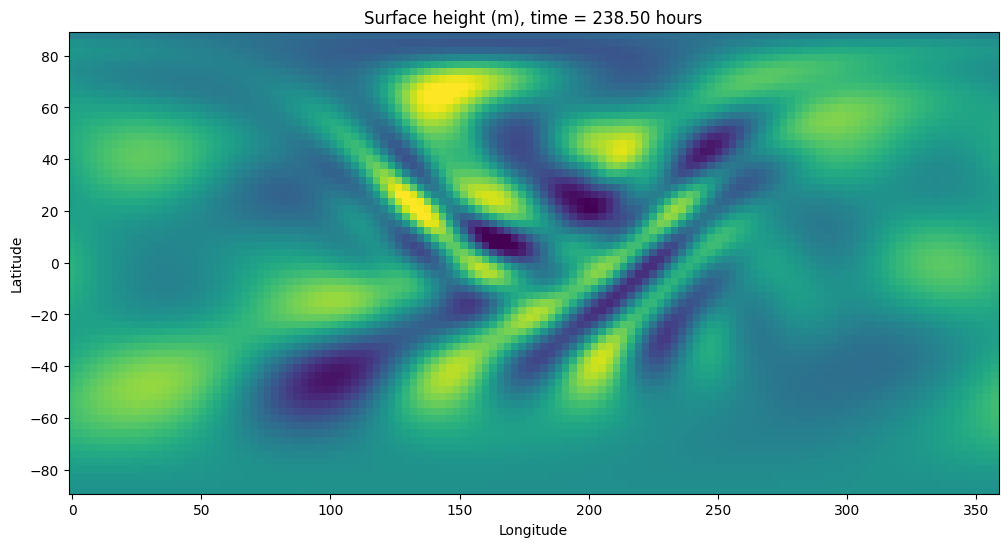

In [183]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(np.pi/2 - theta)*360/2/np.pi, np.squeeze(phi)*360/2/np.pi)

# Define an animation function
def drawframe(n):
    plt.clf()
    height = plt.pcolor(Y, X, h_save[n,:,:], vmin=-0.1, vmax=0.1)
    # Specify the axis limits and labels
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())



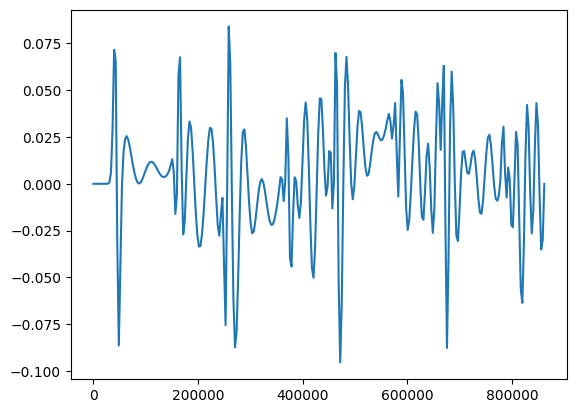

### 3.3 Student investigation
<a id='section3pt3'></a>
Create a virtual tide gauge by sampling the height at a point at a latitude of 45ºN and longitude of 90ºW and plot the timeseries of the height at this point in the cells below. You should modifty the code to save the height more often so that you can clearly see the shape of the wave. Notice that as the waves propagate around the Earth, their shape changes. Discuss physical mechanisms that might cause the shape of the wave to change as the wave propagates.

Text(0, 0.5, 'Wave Height (m)')

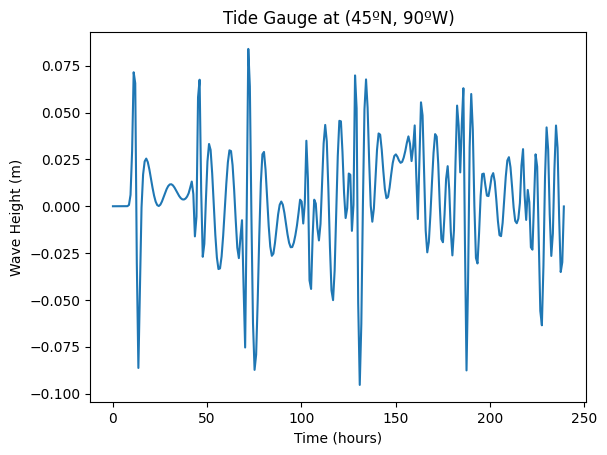

In [234]:
plt.plot(np.array(t_sample)/hour,h_sample)
plt.title('Tide Gauge at (45ºN, 90ºW)')
plt.xlabel('Time (hours)')
plt.ylabel('Wave Height (m)')

Various mechanisms are at play to produce a gauge reading like the one above. The most obvious is interference - the simulation takes place on a sphere (or at least, a flattened one), so wave motion is not in isolation, but there is much interference between waves that loop around. This is one of the primary causes of the small peaks and variations in the waveform. The larger peaks are potentially due to constructive interference (given they are twice the height of some of the smaller peaks). Given we're on a curved surface that is spinning, Rossby and Coriolis effects will be at play. They will cause waves to move up or down the sphere, and this will attenuate the gauge reading until another wave moves in. There is also a larger periodicity, as we can see that there is an overall increase at around 150 hours. This might be due to the Rossby waves which, overtime, become diffuse enough to make a 'background' oscillation, much smaller but with a longer wavelength. We see that at around this time, in the simulation there are many Rossby waves present, insinuating that the background fluid motion, not including the main peaks, is becoming important. The period of the wave is remaining pretty constant, and its amplitude is decreasing. This is most likely due to conservation of energy, where the smaller perturbations are 'coming from' the larger wave, and in doing so take some energy away. This reduces the amplitude of the larger waves.

In the simulation above, the Tsunami wave travels around the planet many times. In reality, the waves will partially dissipate when they reach shorelines. In the spherical shallow water equation code above (or in a new code block below), add a forcing term to the shallow water equations that damps the waves for longitudes larger than $\pm 90^\circ$. Specifically, add a forcing function to the right hand side of the height equation of the following form:

$$ - (1/\tau) f(\phi) h$$

where

$$ f(\phi) = \frac{1}{2}\left(1+tanh\left(\frac{\phi-3\pi/2}{\pi/10}\right)\right) + \frac{1}{2}\left(1-tanh\left(\frac{\phi-\pi/2}{\pi/10}\right)\right) $$

and $\phi$ is the co-latitude in radians and $\tau$ is a damping timescale. A timescale of $\tau=0.1$ days should be sufficient to damp the waves.

With this damping term active, much more slowly propagating waves should be visible. These are shallow water Rossby waves. Estimate the east/west phase speed of these Rossby waves from the theoretical dispersion relation and compare this estimate with the phase speed that you can infer from the simulation by plotting the height, $h$, as a function of longitude and time. Discuss the spatial structure of the Rossby waves and any discrepancies that you see between your estimated and measured phase speeds.

In [296]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Parameters
Nphi = 128 # Number of gridpoints in phi (longitude)
Ntheta = 64 # Number of gridpoints in theta (colatitude)
R = 6.37122e3 * kilometer
Omega = 2 * np.pi / (1 * day) # Earth's angular velocity in radians per second
g = 9.80616 * meter / second**2 # Gravitational acceleration
H = 4 * kilometer # Depth of the ocean
width = 2*np.pi*10/360 # Width of the initial Gaussian in radians
phi0 = np.pi # Longitude of the initial Gaussian height perturbation in radians
theta0 = np.pi/4 # Colatitude of the initial Gaussian height perturbation in radians
tau = 0.1 * day

timestep = 600 * second
stop_sim_time = 10 * day

# Bases
coords = dedalus.S2Coordinates('phi', 'theta')
dist = dedalus.Distributor(coords, dtype=np.float64)
basis = dedalus.SphereBasis(coords, (Nphi, Ntheta), radius=R, dealias=3/2, dtype=np.float64)

# Define the coordinates
phi, theta = dist.local_grids(basis) # Longitude and colatitude
lat = 360*(np.pi / 2 - theta)/(2*np.pi)  # latitude in degrees

# Fields
u = dist.VectorField(coords, name='u', bases=basis)
h = dist.Field(name='h', bases=basis)
f = dist.Field(name='f', bases=basis)
# Operators
# First, create an operator to perform the cross product: "z x ", where z is the local vertical unit vector
# The "skew" operator performs a 90 degree rotation of a vector field,
# so that skew([u,v]) = [-v, u].  MulCosine multiplies by the cosine of the latitude
zcross = lambda A: dedalus.MulCosine(dedalus.skew(A))

# Set the initial conditions
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
h['g'] = np.exp(-((phi-phi0)**2+(theta-theta0)**2)/width**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
# Set the initial velocity to zero
u['g'][0] = 0 # the x-component of the velocity
u['g'][1] = 0 # the y-component of the velocity
f['g'] = 0.5*(1+np.tanh((phi-3*np.pi/2)/(np.pi/10))) + 0.5*(1-np.tanh((phi-np.pi/2)/(np.pi/10)))

# Problem
problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*grad(h) + 2*Omega*zcross(u) = - u@grad(u)")
problem.add_equation("dt(h) + H*div(u) = - div(h*u) - 1/tau*h*f")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time

equator_h_at_time = [np.copy(h['g'][:, 31])] #  samples longitudes at the equator, index = 31
t_sample = [solver.sim_time]

# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 10 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
        if (solver.iteration-1) % 5 == 0:
            h.change_scales(1)
            equator_h_at_time.append(np.copy(h['g'][:, 31])) # sample all longitudes at equator
            t_sample.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save = np.array(h_save)
equator = np.array(equator_h_at_time)


INFO:subsystems:Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 5.4e+01/s


2025-11-20 02:04:53,784 subsystems 0/1 INFO :: Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 5.4e+01/s


INFO:subsystems:Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 6.6e+01/s


2025-11-20 02:04:53,871 subsystems 0/1 INFO :: Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 6.6e+01/s


INFO:subsystems:Building subproblem matrices 14/63 (~22%) Elapsed: 0s, Remaining: 1s, Rate: 6.8e+01/s


...

2025-11-20 02:06:35,404 solvers 0/1 INFO :: Run time (iter 10-end): 94.8 sec


INFO:solvers:CPU time (iter 10-end): 0.02633 cpu-hr


2025-11-20 02:06:35,406 solvers 0/1 INFO :: CPU time (iter 10-end): 0.02633 cpu-hr


INFO:solvers:Speed: 3.648e+05 mode-stages/cpu-sec


2025-11-20 02:06:35,407 solvers 0/1 INFO :: Speed: 3.648e+05 mode-stages/cpu-sec


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-20 01:58:32,942 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpai3gn1hq/temp.m4v


2025-11-20 01:58:32,944 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpai3gn1hq/temp.m4v


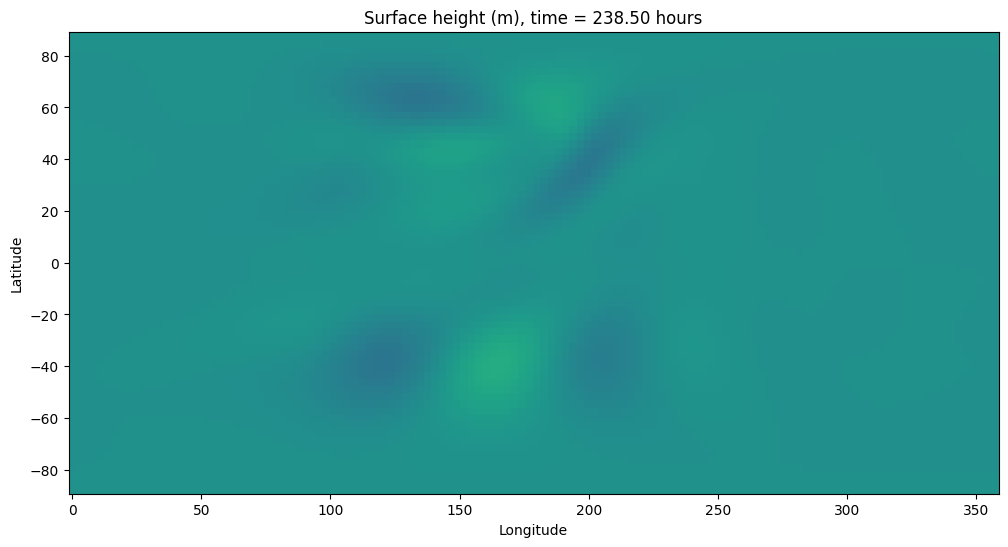

In [294]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(np.pi/2 - theta)*360/2/np.pi, np.squeeze(phi)*360/2/np.pi)

# Define an animation function
def drawframe(n):
    plt.clf()
    height = plt.pcolor(Y, X, h_save[n,:,:], vmin=-0.1, vmax=0.1)
    # Specify the axis limits and labels
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())



In [298]:
print(theta_idx_equator)

31


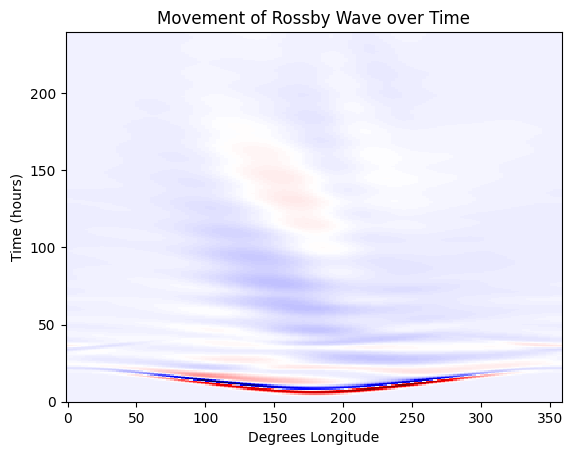

In [297]:
phi_deg = np.squeeze(phi)*360/2/np.pi
time_hours_sample = np.array(t_sample)/hour

# Create mesh grids for pcolor using phi_deg (longitude) and time_hours_sample
# The output (LONG_mesh, T_mesh) will have dimensions (len(time_hours_sample)+1, len(phi_deg)+1)
(LONG_mesh, T_mesh) = plot_tools.quad_mesh(phi_deg, time_hours_sample)

# The data 'equator' has shape (len(time_hours_sample), len(phi_deg))
# which perfectly matches the (M, N) required by pcolor when X, Y are (M+1, N+1).
plt.pcolor(LONG_mesh, T_mesh, equator, cmap = 'seismic')
plt.xlabel('Degrees Longitude')
plt.ylabel('Time (hours)')
plt.title('Movement of Rossby Wave over Time')
plt.show()

We see two features in the above plot of waveheight over time, for a given latitude (taken here at the equator). First, there is the clear line of the initial wave, travelling very fast (low slope), which dissipates also fairly quickly. We also see dimmer patterns that propagate towards the top left corner - these correspond to Rossby waves. We can firstly see that these are much slower, propogating at a much slower slope. We can estimate this using points of constant phase, by noting that the wave moves from 150 degrees to 100 degrees in around 75 minutes, giving a phase velocity of -0.67 degrees/min. This is quite slow compared to the initial wave, implying that it is not a ripple or interference pattern caused by the initial wave, but another emergent phenomenon. The theoretical phase velocity is given by
$$
v_p = \beta/(k^2+l^2) =
$$

## 4. Optional further investigations

* In the example of the shallow water equations on a sphere, introduce bathymetry by making $H$ a function of latitude and longitude. Make sure that you modify the equations in Dedalus appropriately. How do the waves behave when they encounter shallow water (e.g. a localized seamount)?

* It is quite difficult to simulate changing sea level (sometimes called wetting and drying), which is why the examples above do not include land. However, we can estimate the distance that a Tsunami will propagate using physical and dimensional arguments. Consider, for example, a flat, sloping beach. In the absence of energy dissipation, estimate the distance that a wave will propagate onshore. How could you modify this estimate to include energy dissipation (or drag)?